### **Introducción a los biopotenciales y adquisición de señales ECG y EMG**

**Estudiantes**

Luisa María Martínez Muelas

Carolina Taborda Vargas

##### **Registro de ECG en el laboratorio**

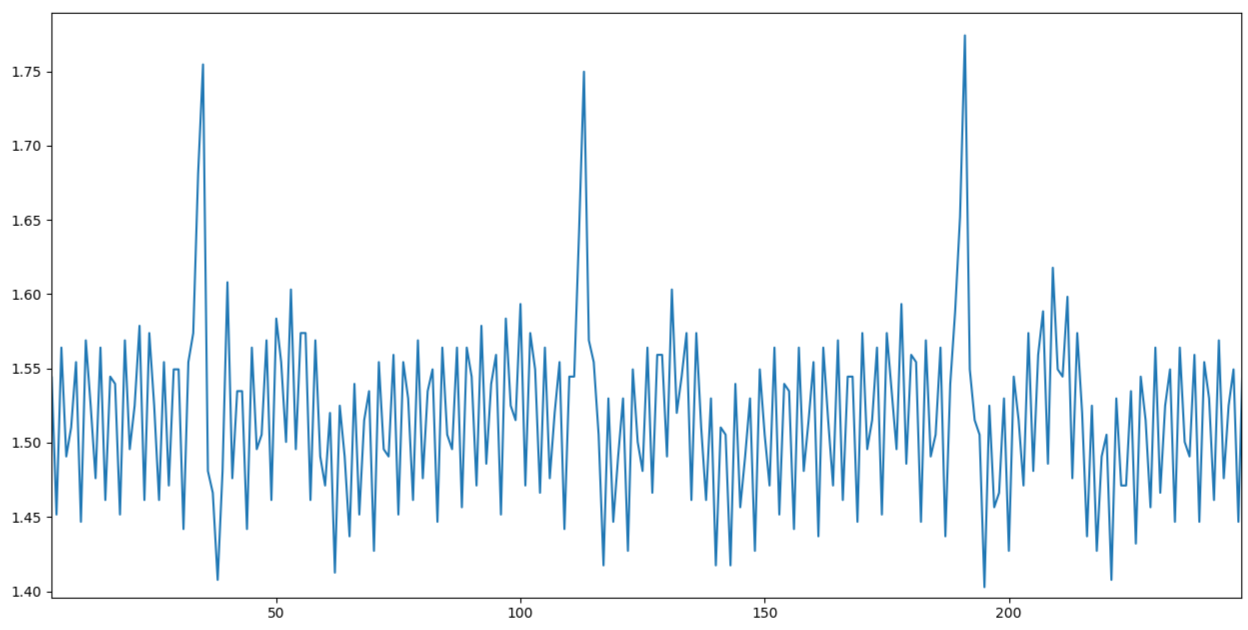

##### **Registro de EMG en el laboratorio**

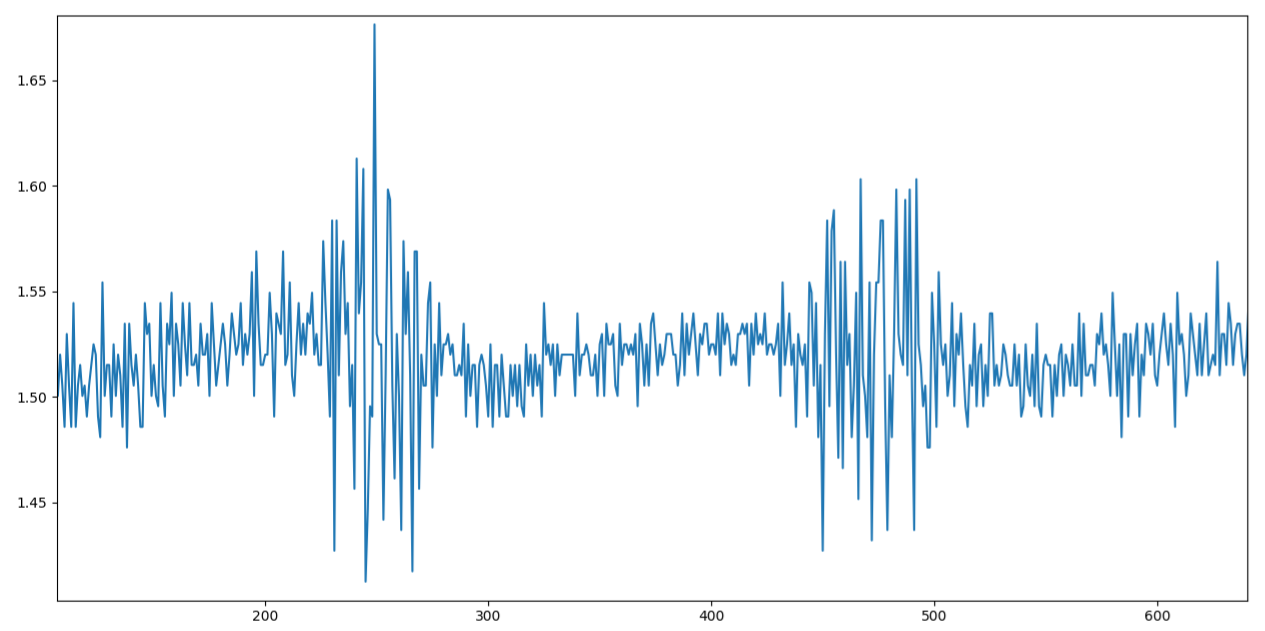

##### **1. Esquema sobre las etapas de registro  de bipotenciales**

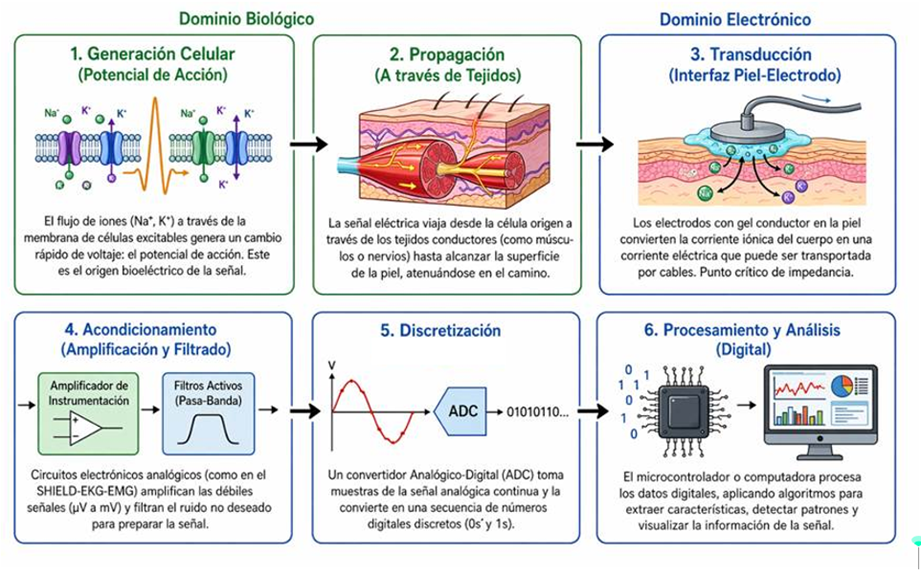

Un sistema de adquisición de biopotenciales, como los utilizados en ECG y EMG, está conformado por varios componentes que permiten captar, acondicionar y procesar señales eléctricas de muy baja amplitud provenientes del cuerpo humano. En primer lugar, los electrodos actúan como la interfaz entre el paciente y el sistema, convirtiendo la corriente iónica generada en los tejidos en una señal eléctrica medible. Posteriormente, la señal es amplificada mediante un amplificador de instrumentación, el cual se caracteriza por su alta impedancia de entrada y elevado rechazo al modo común, permitiendo amplificar señales del orden de microvoltios mientras se minimiza el ruido externo. A continuación, la señal pasa por una etapa de filtrado analógico, donde se eliminan componentes no deseados como el ruido de alta frecuencia, la deriva de la línea base y la interferencia de la red eléctrica. Adicionalmente, el sistema incorpora un módulo de aislamiento, fundamental para garantizar la seguridad del paciente al evitar el paso de corrientes peligrosas desde el equipo. 
Una vez acondicionada, la señal es convertida a formato digital mediante un convertidor analógico-digital (ADC), el cual discretiza la señal en valores numéricos que pueden ser procesados. Seguidamente, una unidad de procesamiento, como un microcontrolador o una computadora, se encarga de analizar la señal mediante algoritmos que permiten extraer información relevante. Finalmente, los datos pueden ser visualizados y almacenados a través de un sistema de visualización y registro, mientras que una fuente de alimentación adecuada asegura el funcionamiento estable de todo el sistema [1].


##### **2. Principales fuentes de ruido en el registro de biopotenciales**

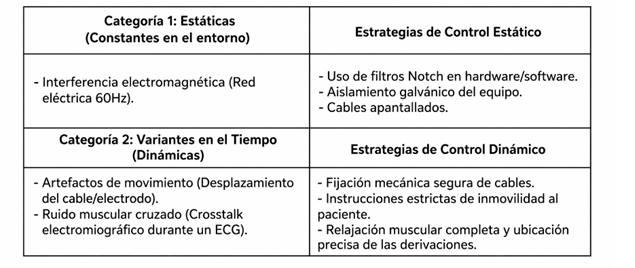

Para las fuentes de ruido estáticas, como la interferencia electromagnética de la red eléctrica a 50/60 Hz, las estrategias se enfocan en reducir la captación constante de estas señales externas. Entre las más utilizadas se encuentran el uso de filtros notch, implementados en hardware o software, que atenúan específicamente la frecuencia de la red eléctrica; el aislamiento galvánico del equipo, que evita el acoplamiento directo de corrientes no deseadas desde la red; y el uso de cables apantallados, los cuales minimizan la inducción de ruido electromagnético externo en los conductores de señal.

Por otro lado, para las fuentes de ruido dinámicas o variantes en el tiempo, como los artefactos de movimiento y el ruido muscular, las estrategias están orientadas a reducir las variaciones físicas durante la medición. Estas incluyen la fijación mecánica adecuada de cables y electrodos para evitar desplazamientos, el uso de instrucciones claras al paciente para mantener la inmovilidad, y la correcta colocación de los electrodos junto con la relajación muscular, lo cual disminuye la interferencia de señales musculares no deseadas. Adicionalmente, una buena preparación de la piel también ayuda a reducir este tipo de artefactos [2][3][4].


##### **3. Problemática asociada al acoplamiento piel-electrodo y estrategias para mejorarlo**


El acoplamiento piel-electrodo constituye una de las principales fuentes de error en la adquisición de biopotenciales, debido a que en esta interfaz ocurre la conversión de corriente iónica propia del cuerpo humano a corriente electrónica medible por el equipo. El principal problema radica en la alta e inestable impedancia de contacto, la cual depende de factores como la presencia de grasa, sudor, vello, células muertas y la presión del electrodo sobre la piel. Esta impedancia no solo atenúa la señal, sino que también introduce ruido, artefactos de movimiento y deriva de la línea base, afectando significativamente la calidad del registro. Además, una mala interfaz puede generar polarización del electrodo y variaciones en el potencial de media celda, lo que distorsiona aún más la señal [5].

Para mejorar el acoplamiento piel-electrodo, se emplean diversas estrategias. Entre las más comunes se encuentran la preparación de la piel, que incluye limpieza con alcohol y, en algunos casos, abrasión suave para reducir la impedancia; el uso de electrodos con gel conductor, como los de Ag/AgCl, que facilitan la conducción iónica. Además, la correcta fijación mecánica para evitar desplazamientos; y el uso de cables apantallados para minimizar la captación de interferencias externas. Asimismo, en el diseño electrónico se utilizan amplificadores con alta impedancia de entrada y alto rechazo al modo común (CMRR) para mitigar los efectos de una interfaz imperfecta [6].


El acoplamiento piel-electrodo es considerado la etapa más crítica en el registro de señales de superficie (sEMG, EEG y ECG) porque es el primer punto de contacto con la señal biológica, y cualquier degradación en esta etapa no puede ser completamente corregida en etapas posteriores. Dado que estas señales son de muy baja amplitud (microvoltios a milivoltios), incluso pequeñas alteraciones en la interfaz pueden representar una pérdida significativa de información o la introducción de artefactos que dificultan su interpretación. En consecuencia, la calidad del acoplamiento determina en gran medida la fidelidad, confiabilidad y utilidad clínica de la señal adquirida [7].





##### **4. Análisis de la Variabilidad de la frecuencia cardíaca (HRV)**

In [ ]:
#Importación de librerías

import neurokit2 as nk
from ecgdetectors import Detectors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [31]:
!git clone https://github.com/Aura-healthcare/hrv-analysis.git
%cd hrv-analysis
! pip install nolds

c:\Users\carol\OneDrive\Escritorio\hrv-analysis


Cloning into 'hrv-analysis'...


In [33]:
from hrvanalysis import get_time_domain_features

#### **Señal en crudo**

In [36]:
#Carga del archivo
data = np.loadtxt('C:/Users/carol/OneDrive/Documentos/Nueva carpeta/OneDrive/Documentos/BIOSEÑALES/P4ECG.txt')

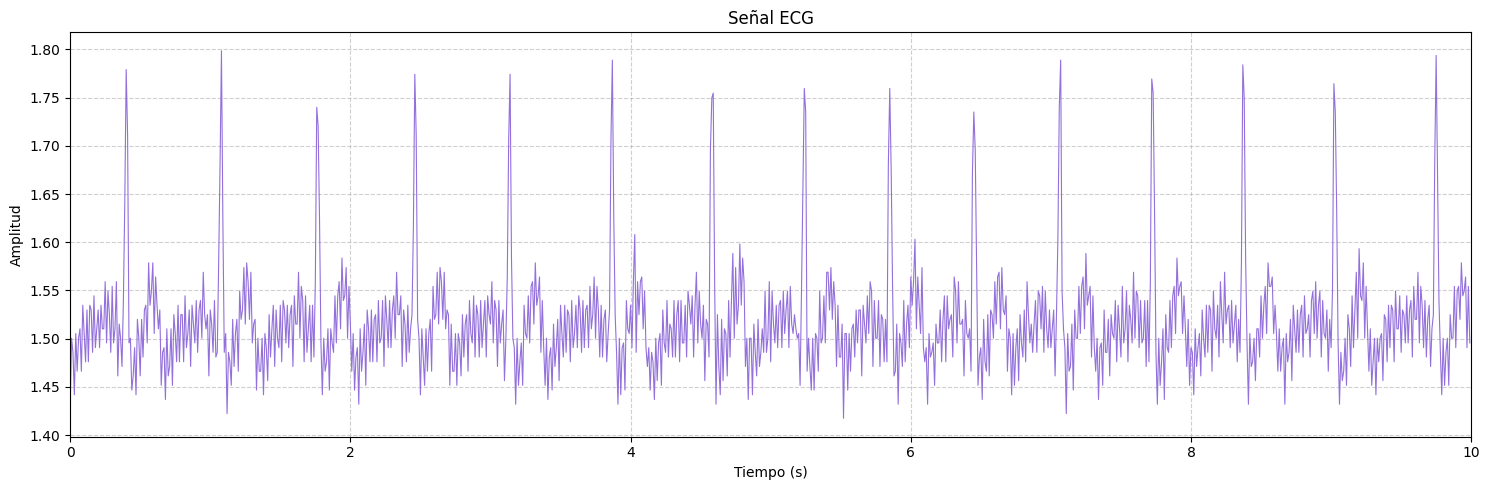

In [ ]:
fs = 100  # Frecuencia de muestreo 
tiempo = np.arange(len(data)) / fs  

plt.figure(figsize=(15, 5))
plt.plot(tiempo, data, color='mediumpurple', linewidth=0.8)

#Gráfica
plt.title("Señal ECG")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud") 
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(0, 10) 

plt.tight_layout()
plt.show()

**4.1. Detección de los picos R utilizando la función de la librería NeuroKit y de Detectors**

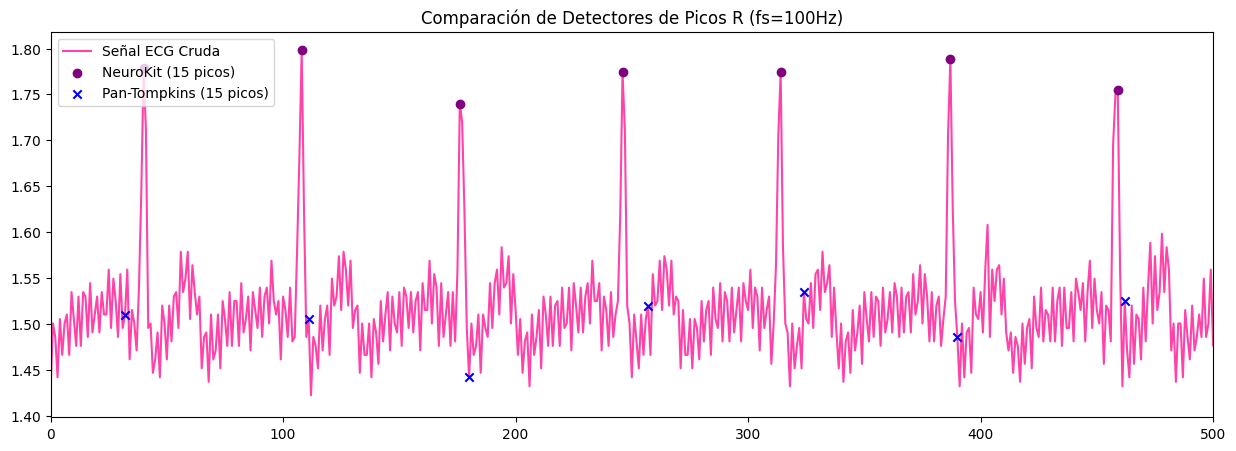

Total picos NeuroKit: 15
Total picos Pan-Tompkins: 15


In [ ]:
#Definimos la frecuencia de muestreo 

fs = 100  # Definido por el delay(10) en el código de arduino que se usó para la recolección de datos en clase 

signals_nk, info_nk = nk.ecg_peaks(data, sampling_rate=fs, method="neurokit")
picos_nk = info_nk["ECG_R_Peaks"]

detectors = Detectors(fs)
picos_pt = detectors.pan_tompkins_detector(data)

# Gráfica
plt.figure(figsize=(15, 5))
plt.plot(data, label="Señal ECG Cruda", color='deeppink', alpha=0.8)
plt.scatter(picos_nk, data[picos_nk], color='purple', label=f'NeuroKit ({len(picos_nk)} picos)', zorder=3)
plt.scatter(picos_pt, data[picos_pt], marker='x', color='blue', label=f'Pan-Tompkins ({len(picos_pt)} picos)', zorder=2)
plt.title("Comparación de Detectores de Picos R (fs=100Hz)")
plt.legend()
plt.xlim(0, 500) 
plt.show()

print(f"Total picos NeuroKit: {len(picos_nk)}")
print(f"Total picos Pan-Tompkins: {len(picos_pt)}")

Tras comparar el desempeño de los algoritmos de detección de picos R, se observa que la librería NeuroKit presentó una precisión superior en la identificación de los complejos QRS para esta señal específica. Mientras que NeuroKit localizó correctamente los picos R de mayor amplitud, el algoritmo de Pan-Tompkins (detectors) presentó múltiples falsos positivos, identificando erróneamente componentes de ruido o picos secundarios como si fueran ondas R.

Esta diferencia en el desempeño puede atribuirse a que la señal adquirida presenta una relación señal-ruido, posiblemente debido a factores críticos como el acoplamiento piel-electrodo o interferencias ambientales captadas durante la discretización con el Arduino Uno.

**4.2. Variabilidad de la frecuencia cardíaca (HRV) a partir de los picos R detectados**

Análisis de HRV
Intervalo RR promedio: 667.86 ms
Frecuencia Cardíaca Promedio: 89.84 BPM
SDNN (Variabilidad Total): 42.46 ms


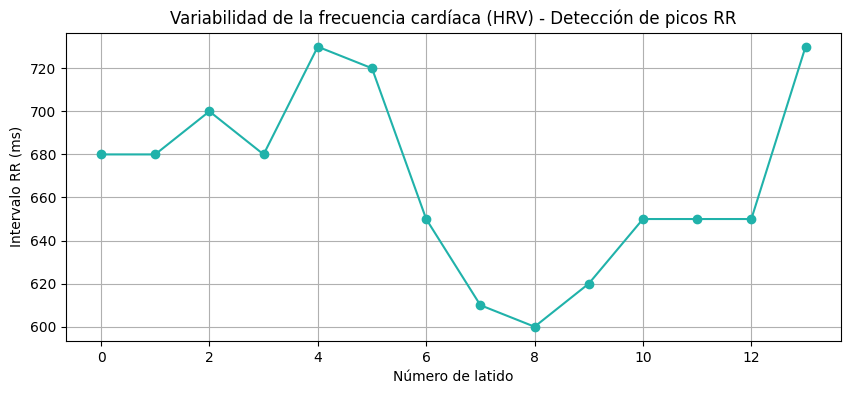

In [ ]:
# CÁLCULO DE LA VARIABILIDAD (HRV)

fs = 100 
# Cálculo de la diferencia entre picos -  Intervalos RR en muestras

rr_muestras = np.diff(picos_nk) 

#Convertimos muestras a tiempo (ms)
rr_intervals = rr_muestras * (1000 / fs)

# Cálculo de métricas
mean_rr = np.mean(rr_intervals)
sdnn_manual = np.std(rr_intervals, ddof=1)
bpm_promedio = 60000 / mean_rr #AQUI TOMAMOS en cuenta que medimos latidos por minuto, por lo tanto, tenemos: 1 minuto tiene 60s x 1,000 = 60.000ms

print(f"Análisis de HRV")
print(f"Intervalo RR promedio: {mean_rr:.2f} ms")
print(f"Frecuencia Cardíaca Promedio: {bpm_promedio:.2f} BPM")
print(f"SDNN (Variabilidad Total): {sdnn_manual:.2f} ms")

# Gráfica
plt.figure(figsize=(10, 4))
plt.plot(rr_intervals, marker='o', linestyle='-', color='lightseagreen')
plt.title("Variabilidad de la frecuencia cardíaca (HRV) - Detección de picos RR")
plt.xlabel("Número de latido")
plt.ylabel("Intervalo RR (ms)")
plt.grid(True)
plt.show()

El análisis de la variabilidad de la frecuencia cardíaca (HRV) revela una frecuencia cardíaca promedio de 89.84 BPM y una desviación estándar de 42.46 ms. Estos valores indican que, aunque el sujeto presenta una frecuencia ligeramente elevada para un estado de reposo absoluto (lo cual podría atribuirse al ruido inherente de la discretización con el ADC del Arduino Uno o al estrés del registro), posee una variabilidad moderada y saludable. 

Las fluctuaciones observadas en los intervalos RR demuestran la capacidad de adaptación del corazón latido a latido, validando que el proceso de adquisición fue lo suficientemente preciso para capturar la arritmia sinusal respiratoria del paciente.

**4.3.Características de HRV en el dominio del tiempo**

In [ ]:
caracteristicas_tiempo = get_time_domain_features(rr_intervals)

print("CARACTERÍSTICAS HRV EXTRAÍDAS (DOMINIO DEL TIEMPO)")

# Métricas 
print(f"Media de intervalos RR (mean_nni): {caracteristicas_tiempo['mean_nni']:.2f} ms")
print(f"SDNN (Variabilidad total):          {caracteristicas_tiempo['sdnn']:.2f} ms")
print(f"RMSSD (Actividad Parasimpática):    {caracteristicas_tiempo['rmssd']:.2f} ms")
print(f"pNN50 (% intervalos > 50ms):        {caracteristicas_tiempo['pnni_50']:.2f} %")
print(f"Frecuencia Cardíaca Media:          {caracteristicas_tiempo['mean_hr']:.2f} bpm")

CARACTERÍSTICAS HRV EXTRAÍDAS (DOMINIO DEL TIEMPO)
Media de intervalos RR (mean_nni): 667.86 ms
SDNN (Variabilidad total):          42.46 ms
RMSSD (Actividad Parasimpática):    36.90 ms
pNN50 (% intervalos > 50ms):        15.38 %
Frecuencia Cardíaca Media:          90.18 bpm


El análisis de los datos permite concluir que el sujeto presenta una frecuencia cardíaca dentro del rango normal, sin embargo, es un poco alto para la condición en la que fueron tomados los datos (reposo). Aún así, esto indica un funcionamiento saludable de su sistema vascular, lo que puede ser evidenciado por medio de los indicadores de variabilidad (SDNN y RMSSD) que confirman que el corazón responde correctamente a los mecanismos de regulación del cuerpo. Estos resultados demuestran que la señal capturada con arduino y el uso de la librería de time domain, tuvo la calidad suficiente para detectar los cambios naturales entre latidos, validando que el contacto de los electrodos con la piel fue efectivo y que el procesamiento digital logró conservar la información biológica más importante.

##### **5. Aplicaciones clínicas del uso de ECG y EMG**

**Electrocardiografía (ECG)**
1. Diagnóstico de arritmias cardíacas: Se registra mediante electrodos superficiales en configuración de 12 derivaciones. El procesamiento incluye detección de complejos QRS con algoritmos como Pan-Tompkins, cálculo del intervalo R-R para análisis de variabilidad, y clasificación automática de ritmos mediante aprendizaje automático.

2. Detección de isquemia e infarto agudo de miocardio: Registro de 12 derivaciones estándar en reposo, o prueba de esfuerzo (ECG de estrés). El procesamiento implica análisis del segmento ST (elevación o depresión), filtrado pasa-banda (0.05–150 Hz) para eliminar artefactos de movimiento, y promediado de señal para mejorar la relación señal-ruido.

3. Evaluación de síndromes de conducción: Registro estándar de 12 derivaciones en reposo. El procesamiento comprende medición de duraciones de intervalos (PR, QRS, QT), análisis morfológico de la onda P y del complejo QRS, y algoritmos de interpretación automática comparando con bases de datos de patrones [8]. 

**Electromiografía (EMG)**

1. Diagnóstico de enfermedades neuromusculares (miopatías y neuropatías): Se emplea EMG de aguja intramuscular en reposo, contracción mínima y máxima. El procesamiento incluye análisis de potenciales de unidad motora (PUM): duración, amplitud y fases; detección de actividad espontánea patológica y análisis espectral con FFT para evaluar fatiga muscular.

2. Estudios de conducción nerviosa y electrodiagnóstico de lesiones: Se utiliza EMG de superficie con estimulación eléctrica percutánea del nervio. El procesamiento mide latencias distales, velocidades de conducción motora y sensitiva, y amplitud del potencial de acción compuesto, comparando valores con rangos normativos por edad.

3. Biorretroalimentación (biofeedback) y rehabilitación neuromuscular: Se registra mediante EMG de superficie (electrodos de Ag/AgCl) sobre el músculo objetivo. El procesamiento incluye rectificación y suavizado de la señal. Además, la extracción de características en tiempo real (amplitud, frecuencia mediana), y retroalimentación visual o sonora al paciente para reeducar el control motor tras lesiones o ACV [8].



##### **Conclusiones**

- Se logró transformar una señal de ECG contaminada por ruido eléctrico y movimientos del sujeto en una señal biológica limpia y analizable. Esto demuestra que el uso de filtros digitales (como los de la librería neurokit2) es indispensable en la ingeniería biomédica para corregir las limitaciones del hardware básico, permitiendo que el Arduino Uno entregue datos con calidad suficiente para el diagnóstico preliminar.

- La comparación de algoritmos reveló que la detección de los picos R es el paso más crítico para un análisis confiable. Se concluye que, ante señales adquiridas con equipos que pueden presentar margen de error, es preferible utilizar herramientas de procesamiento robustas (como NeuroKit) que logren diferenciar correctamente el complejo QRS del ruido residual, asegurando que los cálculos posteriores no sean alterados por datos que pueden actuar como falsos positivos e impiden ver con claridad la señal para su correcto diagnóstico.

- Los indicadores obtenidos en el dominio del tiempo confirman que el corazón del sujeto evaluado posee una buena capacidad de adaptación. Aunque factores externos como el estrés de la prueba pudieron elevar la frecuencia cardíaca, movimientos o incluso la adaptación de los electrodos con la piel;  los valores de variabilidad demuestran un equilibrio saludable en la regulación del sistema nervioso. Esto valida el éxito de la práctica, al demostrar que es posible monitorear el estado funcional del paciente a través de la interpretación correcta de los intervalos entre latidos.



#### **Referencias**

[1] Analog Devices. (s.f.). Biopotential electrode sensors in ECG/EEG/EMG systems. https://www.analog.com/en/resources/technical-articles/biopotential-electrode-sensors-ecg-eeg-emg.html

[2] Mains, E., & Sörnmo, L. (2005). Removal of power-line interference from the ECG: A review of the subtraction procedure. Springer BioMedical Engineering OnLine, 4, 50. https://doi.org/10.1186/1475-925X-4-50

[3] Chen, Z., Wang, J., & Liu, W. (2018). Effective biopotential signal acquisition: Comparison of different shielded drive technologies. MDPI Applied Sciences, 8(2), 276. https://doi.org/10.3390/app8020276


[4] Leonhardt, S., Leicht, L., & Teichmann, D. (2024). Motion artifacts in capacitive ECG monitoring systems: A review of existing models and reduction techniques. PubMed Central Medical & Biological Engineering & Computing, 62, 3–25. https://doi.org/10.1007/s11517-024-03165-1

[5] Analog Devices. (s.f.). Biopotential electrode sensors in ECG/EEG/EMG systems. Analog https://www.analog.com/en/resources/technical-articles/biopotential-electrode-sensors-ecg-eeg-emg.html


[6] Rodrigues, D., Barbosa, A. I., Rebelo, R., Kwon, I. K., Reis, R. L., & Correlo, V. M. (2021). Time evolution of the skin–electrode interface impedance under different skin treatments. PubMed Central Sensors, 21(15), 5210. https://doi.org/10.3390/s21155210


[7] Barón-Lara, M. N., Suaste-Gómez, E., & Torres-Peralta, R. (2022). Dependence of skin-electrode contact impedance on material and skin hydration. nih Sensors, 22(21), 8510. https://doi.org/10.3390/s22218510


[8] Task Force of the European Society of Cardiology and the North American Society of Pacing and Electrophysiology. (1996). Heart rate variability: Standards of measurement, physiological interpretation, and clinical use. Washington University Circulation, 93(5), 1043–1065. https://doi.org/10.1161/01.cir.93.5.1043